# Seminární práce 2

In [1]:
import wfdb
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import librosa as lib
import seaborn as sns
with open("./voiced-database/RECORDS", "r") as f:
    records = f.readlines()
records = [record.strip() for record in records]

Pravděpodobně chybný záznam v anotacích, diagnóza je napsaná s překlepem a oficiálně je anotováno 58 zdravých hlasů, avšak po výpisu pouze zdravých jich naleznu pouze 57
voice143 ['<age>: 43 <sex>: F <diagnoses>: hyperkineti dysphonia <medications>: none']

In [2]:
def load_data(path, from_sample = 0,to_sample=None):
    signals, fields = wfdb.rdsamp(path, sampfrom=from_sample, sampto=to_sample)
    voice = signals[:, 0].flatten()
    return voice, fields

def signal_cut(signal):
    ids = np.array(np.nonzero(signal))
    id1 = ids[0,0]
    SignalFlip = np.flip(signal)
    ids = np.array(np.nonzero(SignalFlip))
    id2 = signal.size - ids[0,0]-1
    SignalCut = signal[id1:id2]
    SignalCut = np.hamming(SignalCut.size)*SignalCut

    return np.array(SignalCut)

def perform_fft(signal):
    signal = np.fft.fft(signal)
    signal = np.abs(signal)
    signal = np.log(signal)
    signal = np.fft.ifft(signal)
    signal = np.abs(signal)

    return np.array(signal)

def get_f0(signal, fs):
    minq = fs // 300
    maxq = fs // 70
    peaks = np.argmax(signal[minq:maxq]) + minq
    f0 = fs/peaks
    return f0

def classify_voice_f0(f0, threshold=155):
    """ Klasifikace hlasu na základě F0 """
    return 1 if f0 > threshold else 0 # 0 healthy

def draw_classification(f0sfemale, f0smale, femthresh, malethresh, colorsfem, colorsmale):
    plt.figure(figsize=(12, 5))
    plt.scatter(range(len(f0smale)), f0smale, c=colorsmale, label="Muži")
    plt.scatter(range(len(f0sfemale)), f0sfemale, c=colorsfem, label="Ženy", marker="x")
    plt.axhline(y=femthresh, color="blue", linestyle="--", label=f"Prahová hodnota {femthresh} Hz ženy")
    plt.axhline(y=malethresh, color="purple", linestyle="--", label=f"Prahová hodnota {malethresh} Hz muži")
    plt.xlabel("Vzorky")
    plt.ylabel("F0 (Hz)")
    plt.title("Základní frekvence (F0) jednotlivých vzorků")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.show()


Detekované zdravé hlasy: 58 Detekované zdravé dle anotací: 9
Detekované patologické hlasy: 150 Detekované patologické dle anotací: 102
Zdravé dle anotací: 15.79 %
Zdravé dle detekce: 101.75 %
Patologické dle anotací: 67.55 %
Patologické dle detekce: 99.34 %
Celková úspěšnost: 53.37 %


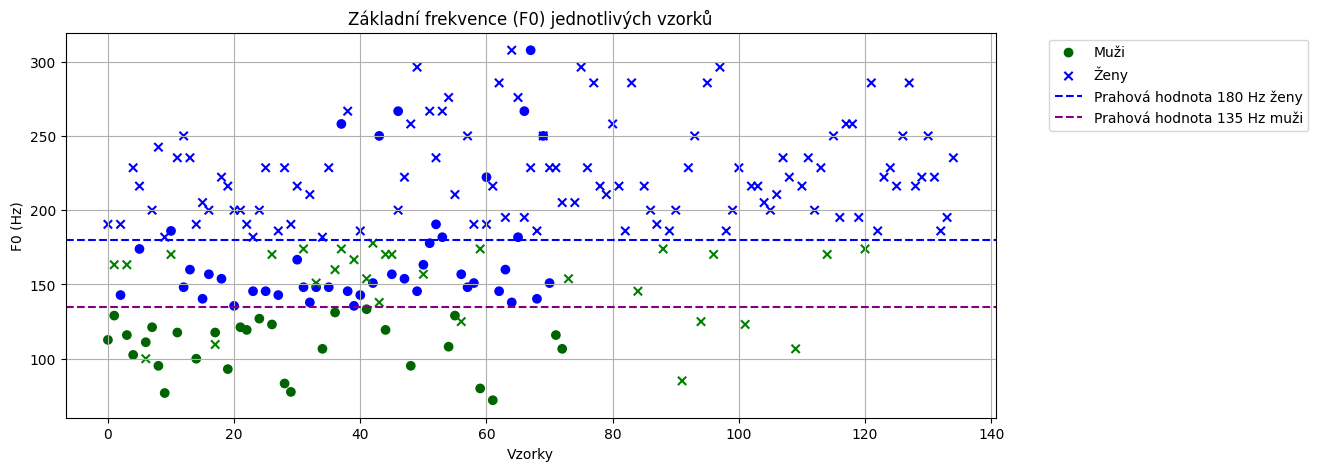

In [3]:
corr_healthy = 0
healthy = 0
pathol = 0
corr_healthy = 0
corr_pathol = 0
f0s = []
f0smale = []
femthresh = 180
f0sfemale = []
malethresh = 135
threshold = 150

for record in records:
    path = f"./voiced-database/{record}"
    voice, fields = load_data(path)
    fs = fields["fs"]
    voice = signal_cut(voice)
    voice = perform_fft(voice)
    f0 = get_f0(voice, fs)
    if "F" in fields['comments'][0]:
        threshold = femthresh
        f0s.append(f0)
        f0sfemale.append(f0)
        classif = classify_voice_f0(f0, threshold)
        if classif == 0:
            healthy += 1
            if "heal" in fields["comments"][0]:
                corr_healthy += 1
        else:
            pathol += 1
            if "heal" not in fields["comments"][0]:
                corr_pathol += 1
    else:
        threshold = malethresh
        f0s.append(f0)
        f0smale.append(f0)
        classif = classify_voice_f0(f0, threshold)
        if classif == 0:
            healthy += 1
            if "heal" in fields["comments"][0]:
                corr_healthy += 1
        else:
            pathol += 1
            if "heal" not in fields["comments"][0]:
                corr_pathol += 1

print("Detekované zdravé hlasy:",healthy, "Detekované zdravé dle anotací:",corr_healthy)
print("Detekované patologické hlasy:",pathol, "Detekované patologické dle anotací:",corr_pathol)
print(f"Zdravé dle anotací: {np.round(corr_healthy/57*100, 2)} %")
print(f"Zdravé dle detekce: {np.round(healthy/57*100, 2)} %")
print(f"Patologické dle anotací: {np.round(corr_pathol/151*100, 2)} %")
print(f"Patologické dle detekce: {np.round(pathol/151*100, 2)} %")
print(f"Celková úspěšnost: {np.round((corr_healthy+corr_pathol) / (healthy+pathol) * 100,2)} %")
f0smale = np.array(f0smale)
f0sfemale = np.array(f0sfemale)
colorsfem = ["green" if f < femthresh else "blue" for f in f0sfemale]
colorsmale = ["darkgreen" if f < malethresh else "blue" for f in f0smale]

draw_classification(f0sfemale=f0sfemale, f0smale=f0smale, femthresh=femthresh, malethresh=malethresh, colorsfem=colorsfem, colorsmale=colorsmale)

In [4]:
def mfcc(signal, fs):
    mfcc = lib.feature.mfcc(y= signal, sr = fs, n_mfcc=13)
    return np.mean(mfcc, axis=1)

def hnr(signal):
    stft = lib.stft(signal)
    magnitude = np.abs(stft)
    harmonic, noise = lib.decompose.hpss(magnitude)
    harmonic_energy = np.sum(harmonic**2, axis=0)
    noise_energy = np.sum(noise**2, axis=0)
    hnr = 10 * np.log10(harmonic_energy / (noise_energy + 1e-10))
    return np.mean(hnr)

def zcr(signal):
    zcr = lib.feature.zero_crossing_rate(signal)[0]
    return np.mean(zcr)

def spectral_centroid(signal,fs):
    spectral_centroid = lib.feature.spectral_centroid(y=signal, sr=fs)
    return np.mean(spectral_centroid)

def classify_voice(hnr_val, mfcc_val, zcr_val, centroid_val, thresholds = [22, -65, 0.35, 970]):
    hnr_threshold = thresholds[0]             # 22
    mfcc_threshold = thresholds[1]            # -65
    zcr_threshold = thresholds[2]             # 0.35
    centroid_threshold = thresholds[3]        # 970
    
    if hnr_val < hnr_threshold or zcr_val > zcr_threshold or centroid_val < centroid_threshold or mfcc_val < mfcc_threshold:
        return "Patologický"
    return "Zdravý"

def classify_hnr(hnr_val, threshold):
    if hnr_val < threshold:
        return "Patologický"
    return "Zdravý"


def draw_bar(healthy, pathol):
    plt.figure(figsize=(6, 4))
    categories = ["Zdravý", "Patologický"]
    counts = [healthy, pathol]
    plt.bar(categories, counts, color=["green", "blue"])
    plt.ylabel("Počet vzorků")
    plt.title("Počet klasifikovaných zdravých a patologických vzorků")
    plt.show()

def draw_confusion_matrix(corr_healthy, corr_pathol, healthy, pathol):
    conf_matrix = np.array([[corr_healthy, healthy - corr_healthy],
                        [pathol - corr_pathol, corr_pathol]])

    plt.figure(figsize=(5, 4))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred. Zdravý", "Pred. Patologický"], 
                yticklabels=["Skut. Zdravý", "Skut. Patologický"])
    plt.title("Maticová reprezentace klasifikace (Confusion Matrix)")
    plt.xlabel("Predikce")
    plt.ylabel("Skutečnost")
    plt.show()

def draw_distributions(hnr_values, mfcc_values, zcr_values, centroid_values):
    feature_names = ["HNR", "MFCC", "ZCR", "Centroid"]
    feature_values = [hnr_values, mfcc_values, zcr_values, centroid_values]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    for ax, feature, values in zip(axes.flat, feature_names, feature_values):
        ax.hist(values, bins=20, alpha=0.7, color="purple", edgecolor="black")
        ax.axvline(np.mean(values), color="red", linestyle="--", label="Průměr")
        ax.set_title(f"Distribuce {feature}")
        ax.set_xlabel(feature)
        ax.set_ylabel("Počet vzorků")
        ax.legend()

    plt.tight_layout()
    plt.show()

Detekované zdravé hlasy: 48 Detekované zdravé dle anotací: 23
Detekované patologické hlasy: 160 Detekované patologické dle anotací: 126
Zdravé dle anotací: 40.35 %
Zdravé dle detekce: 84.21 %
Patologické dle anotací: 83.44 %
Patologické dle detekce: 105.96 %
Celková úspěšnost: 71.63 %


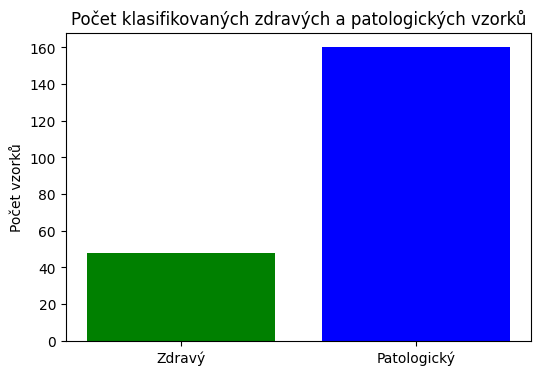

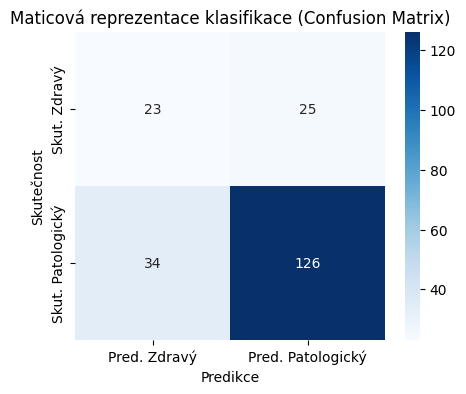

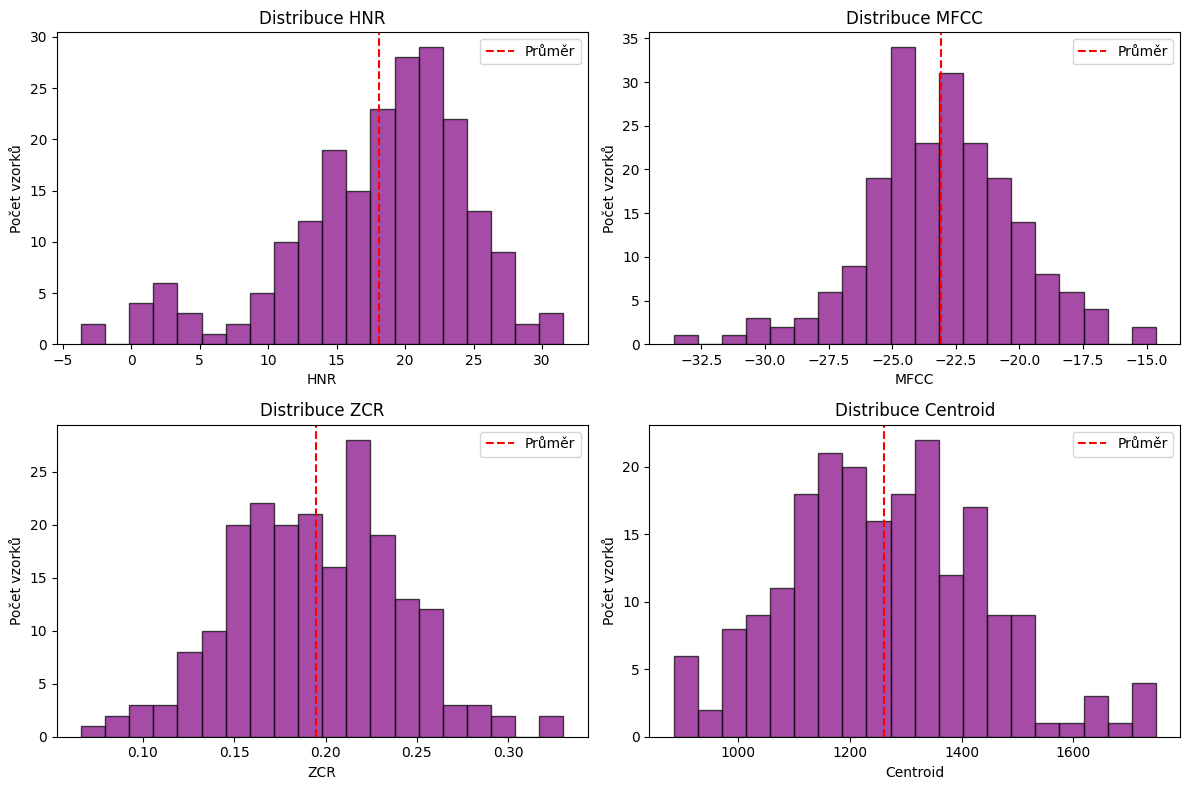

In [5]:
corr_healthy = 0
healthy = 0
pathol = 0
corr_healthy = 0
corr_pathol = 0

hnr_values = []
mfcc_values = []
zcr_values = []
centroid_values = []

hnr_threshold = 22.38
mfcc_threshold = -30
zcr_threshold = 0.35
centroid_threshold = 970
thresholds = [hnr_threshold, mfcc_threshold, zcr_threshold, centroid_threshold]
for record in records[0:]:
    path = f"./voiced-database/{record}"
    voice, fields = load_data(path)
    fs = fields["fs"]
    voice = signal_cut(voice)
    mfcc_ = np.mean(mfcc(voice, fs))
    hnr_ = hnr(voice) 
    zcr_ = zcr(voice)
    centroid_ = spectral_centroid(voice, fs)
    classification = classify_voice(hnr_, mfcc_, zcr_,centroid_, thresholds)
    
    hnr_values.append(hnr_)
    mfcc_values.append(mfcc_)
    zcr_values.append(zcr_)
    centroid_values.append(centroid_)

    actual_class = "Zdravý" if "heal" in fields["comments"][0] else "Patologický"

    if classification == "Zdravý":
        healthy += 1
        if actual_class == "Zdravý":
            corr_healthy += 1
    else:
        pathol += 1
        if actual_class == "Patologický":
            corr_pathol += 1

print("Detekované zdravé hlasy:",healthy, "Detekované zdravé dle anotací:",corr_healthy)
print("Detekované patologické hlasy:",pathol, "Detekované patologické dle anotací:",corr_pathol)
print(f"Zdravé dle anotací: {np.round(corr_healthy/57*100, 2)} %")
print(f"Zdravé dle detekce: {np.round(healthy/57*100, 2)} %")
print(f"Patologické dle anotací: {np.round(corr_pathol/151*100, 2)} %")
print(f"Patologické dle detekce: {np.round(pathol/151*100, 2)} %")
print(f"Celková úspěšnost: {np.round((corr_healthy+corr_pathol) / (healthy+pathol) * 100,2)} %")

draw_bar(healthy, pathol)

draw_confusion_matrix(corr_healthy=corr_healthy, corr_pathol=corr_pathol, healthy=healthy, pathol = pathol)

draw_distributions(hnr_values, mfcc_values, zcr_values, centroid_values)

In [6]:
corr_healthy = 0
healthy = 0
pathol = 0
corr_healthy = 0
corr_pathol = 0

hnr_values = []

hnr_threshold = 22.38
for record in records[0:]:
    path = f"./voiced-database/{record}"
    voice, fields = load_data(path)
    fs = fields["fs"]
    voice = signal_cut(voice)
    hnr_ = hnr(voice)
    classification = classify_hnr(hnr_, hnr_threshold)
    
    hnr_values.append(hnr_)

    actual_class = "Zdravý" if "heal" in fields["comments"][0] else "Patologický"

    if classification == "Zdravý":
        healthy += 1
        if actual_class == "Zdravý":
            corr_healthy += 1
    else:
        pathol += 1
        if actual_class == "Patologický":
            corr_pathol += 1

print("Detekované zdravé hlasy:",healthy, "Detekované zdravé dle anotací:",corr_healthy)
print("Detekované patologické hlasy:",pathol, "Detekované patologické dle anotací:",corr_pathol)
print(f"Zdravé dle anotací: {np.round(corr_healthy/57*100, 2)} %")
print(f"Zdravé dle detekce: {np.round(healthy/57*100, 2)} %")
print(f"Patologické dle anotací: {np.round(corr_pathol/151*100, 2)} %")
print(f"Patologické dle detekce: {np.round(pathol/151*100, 2)} %")
print(f"Celková úspěšnost: {np.round((corr_healthy+corr_pathol) / (healthy+pathol) * 100,2)} %")

Detekované zdravé hlasy: 53 Detekované zdravé dle anotací: 25
Detekované patologické hlasy: 155 Detekované patologické dle anotací: 123
Zdravé dle anotací: 43.86 %
Zdravé dle detekce: 92.98 %
Patologické dle anotací: 81.46 %
Patologické dle detekce: 102.65 %
Celková úspěšnost: 71.15 %
